# 10 · GNN: 이웃에게서 모으고, 모든 노드에 같은 규칙 쓰기

**이번 질문:** 이미지의 격자나 시간 순서가 아니라, 연결 관계만 주어졌다면 어떤 입력을 모아서 같은 함수를 적용해야 할까요?

05번은 옆 화소를, 06번은 이전 시각을, 08번은 점수가 높은 위치를 읽었습니다. 이번에는 **주어진 edge**가 누구를 읽을지 정합니다.
인접 행렬 → 합·평균 집계 → message passing backward → graph readout → 그래프 분류 → 순열 검산과 표현 한계를 구현합니다. 00의 행렬곱, 03의 MLP, 05·06의 가중치 공유를 연결합니다.

- 준비물: [00](../00_기초/00_math_to_numpy.ipynb)의 행렬곱, [03](../00_기초/03_perceptron_to_mlp.ipynb)의 MLP backward, [05](05_cnn.ipynb)·[06](06_rnn.ipynb)의 "공유한 파라미터의 기울기는 더한다".
- 도착점: 한 층의 message passing과 backward를 직접 쓰고 검산한 뒤, 사슬·별 그래프 분류를 학습시키고 노드 번호를 바꿔도 같은 답이 나오는지 검산합니다.
- 다음 연결: 기본 아키텍처 05–10이 끝납니다. [11 선형대수](../02_연결/11_linear_algebra.ipynb)부터는 구조가 아니라 학습 목적과 표현을 다룹니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 인접 행렬의 방향을 먼저 정합니다. $A_{ij}=1$은 **$j$가 $i$에게 보낸다**는 뜻이고, 이웃 합은 `A @ X`, 이웃 평균은 degree로 나눈 `S @ X`입니다. 행이 받는 노드, 열이 보내는 노드입니다.
2. 한 층은 모든 노드에 같은 두 가중치를 씁니다. `Z = X @ Ws + (S @ X) @ Wn + b`, `H = np.tanh(Z)`. backward에서 이웃 경로는 **S의 전치**로 돌아갑니다. `dX = dZ @ Ws.T + S.swapaxes(-1, -2) @ (dZ @ Wn.T)`.
3. 노드 번호를 바꾸면 `X[perm]`, `A[perm][:, perm]`처럼 행과 열을 함께 바꿉니다. 노드 출력은 같은 순열로 바뀌고(등변), 평균 readout과 그래프 logits는 그대로입니다(불변).

📎 여기서는 작고 조밀한 인접 행렬을 씁니다. 대규모 sparse 연산이나 라이브러리 호출 안에 집계·미분을 숨기지 않고, 계산을 직접 확인하는 것이 목적입니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/gnn_plots.py)

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.utils.gnn_plots import (
    plot_curves, plot_aggregation, plot_layer_paths, plot_hops, plot_two_graphs, plot_permutation,
)
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· GNN 준비 완료")

NumPy 2.3.5 · GNN 준비 완료


### 📎 이 노트북의 예시: 3노드 방향 그래프, 5노드 사슬, 사슬과 별

- **3노드 방향 그래프.** 노드 0은 1·2에게서 받고, 2는 0에게서 받고, 1은 아무에게도 받지 않습니다. 집계·한 층·순열을 손으로 계산합니다.
- **5노드 사슬.** 층을 쌓을 때 정보가 닿는 범위를 봅니다.
- **사슬과 별.** 노드 6개·edge 5개로 같지만 모양이 다른 두 그래프를 분류합니다. 4절에서 본문 코드로 만듭니다.

MNIST는 쓰지 않습니다. 그래프에는 격자가 없어 이미지 예시가 맞지 않기 때문입니다.

In [2]:
tri_positions = np.array([[0., 0.9], [-0.9, -0.5], [0.9, -0.5]])     # 3노드 그림 좌표
line5_positions = np.stack([np.arange(5) * 1.0, np.zeros(5)], axis=1)   # 5노드 사슬 그림 좌표
print("그림 좌표 준비:", tri_positions.shape, line5_positions.shape)

그림 좌표 준비: (3, 2) (5, 2)


## 🔑 1. 인접 행렬의 방향을 먼저 정하기

**이 절에서 가져갈 것:** $A_{ij}=1$을 "$j$가 $i$에게 보낸다"로 정하면 이웃 합은 $AX$ 한 번의 행렬곱입니다. 행이 받는 노드, 열이 보내는 노드입니다. 평균 집계는 각 행을 그 노드의 degree로 나눈 $S$를 씁니다.

친구 세 명이 쪽지를 돌린다고 합시다. 1과 2는 0에게 보내고, 0은 2에게 보내고, 1은 받는 쪽지가 없습니다. 0이 받은 쪽지의 합은 1과 2의 특성을 더한 것이고, 평균은 그것을 2로 나눈 것입니다. 이 "누가 누구에게"를 0/1 표로 적은 것이 인접 행렬입니다.

> **용어**
>
> - **그래프(graph)·노드(node)·edge**: 점(노드)과 점 사이의 연결(edge). 노드 수 $M$, 특성 폭 $D$, 그래프 배치 $B$로 `X:(B,M,D)`, `A:(B,M,M)`.
> - **인접 행렬(adjacency matrix)** $A$: $A_{ij}=1$이면 $j$에서 $i$로 정보를 보낼 수 있음. 대각선은 0으로 두고 자기 정보는 별도 경로로 씁니다.
> - **degree**·**집계(aggregation)**: degree $d_i=\sum_jA_{ij}$는 받는 이웃 수. 집계는 이웃의 특성을 합하거나 평균내는 것. 코드에서는 `A @ X`, `S @ X`.

노드 수를 M, 특성 폭을 D, 그래프 배치 크기를 B라고 씁니다. `X:(B,M,D)`, `A:(B,M,M)`입니다. **$A_{ij}=1$은 j에서 i로 정보를 보낼 수 있다는 뜻**으로 정합니다. 그러면
$$m_i=\sum_j A_{ij}x_j,\qquad M_{sum}=AX.$$

노드 $i$가 받는 메시지는 $i$에게 보내는 노드들의 특성 합이고, 모든 노드를 한꺼번에 쓰면 행렬곱 $AX$입니다.

행 i는 받는 노드, 열 j는 보내는 노드입니다. 무방향 그래프이면 A가 대칭이지만, 방향이 있는 경우도 같은 식으로 처리할 수 있습니다. A의 대각선은 0으로 두고 자기 자신의 정보는 별도 경로로 사용합니다.

평균 집계는 degree $d_i=\sum_j A_{ij}$로 나눕니다.
$$S_{ij}=A_{ij}/\max(d_i,1),\quad M_{mean}=SX.$$
입력 A가 0/1일 때 degree는 들어오는 이웃 수입니다. 이웃이 없는 행은 0으로 남습니다. 이웃 평균만으로 자기 자신을 잃지 않도록 다음 절에서 self 경로를 둡니다.

아래는 3노드 예제의 손계산입니다.

In [3]:
agg_A = np.array([[0., 1., 1.],
                  [0., 0., 0.],
                  [1., 0., 0.]])                                    # (3, 3): 행 = 받는 노드, 열 = 보내는 노드
agg_X = np.array([[1., 2.], [3., 4.], [5., 8.]])                     # (3, 2) 노드별 특성
agg_sum = agg_A @ agg_X                                             # (3, 2) 이웃 합
agg_degree = agg_A.sum(axis=-1, keepdims=True)                      # (3, 1) 받는 이웃 수 [2, 0, 1]
agg_S = agg_A / np.maximum(agg_degree, 1)                           # (3, 3) 평균 집계 행렬
agg_mean = agg_S @ agg_X                                            # (3, 2) 이웃 평균
print("degree", agg_degree.ravel(), "\n이웃 합\n", agg_sum, "\n이웃 평균\n", agg_mean)

degree [2. 0. 1.] 
이웃 합
 [[ 8. 12.]
 [ 0.  0.]
 [ 1.  2.]] 
이웃 평균
 [[4. 6.]
 [0. 0.]
 [1. 2.]]


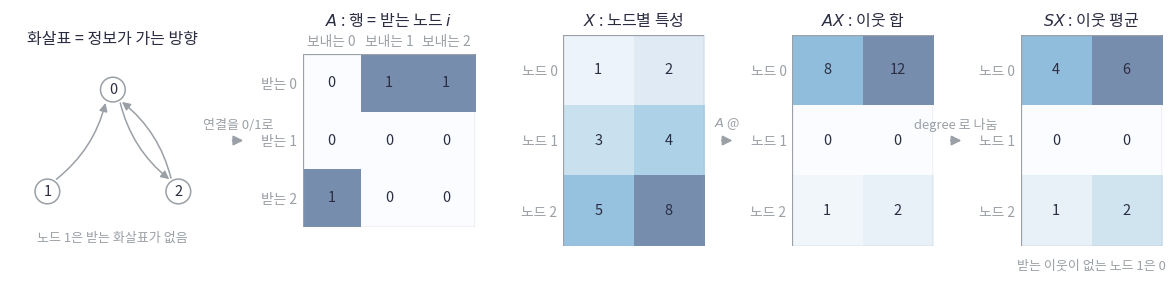

In [4]:
plot_aggregation(agg_A, tri_positions, agg_X, agg_sum, agg_mean)

🔍 **확인** · 노드 0의 행은 `[0, 1, 1]`이라 1과 2의 특성을 더한 `[8, 12]`를 받고, degree 2로 나누면 평균 `[4, 6]`입니다. 노드 1의 행은 모두 0이라 합도 평균도 0입니다. 노드 2는 0에게서만 받아 합과 평균이 같습니다.
화살표 방향과 행렬의 행·열을 맞추는 것이 이 절의 전부입니다. 아래 구현은 배치 축을 포함한 집계 행렬과, 검산용 반복문 집계입니다.

In [5]:
def aggregation_matrix(A, mode="sum"):
    assert mode in ("sum", "mean")
    assert A.ndim == 3 and A.shape[-1] == A.shape[-2]
    assert np.all((A == 0) | (A == 1)), "이 구현의 입력 인접 행렬은 0/1입니다"
    if mode == "sum":
        return A
    degree = A.sum(axis=-1, keepdims=True)
    return A / np.maximum(degree, 1)


def aggregate_loops(X, S):
    B, M, D = X.shape
    messages = np.zeros_like(X)
    for b in range(B):
        for i in range(M):
            for j in range(M):
                messages[b, i] += S[b, i, j] * X[b, j]
    return messages

In [6]:
A_hand = np.array([[[0., 1., 1.], [0., 0., 0.], [1., 0., 0.]]])
X_hand = np.array([[[1., 2.], [3., 4.], [5., 8.]]])
sum_messages = A_hand @ X_hand
mean_messages = aggregation_matrix(A_hand, "mean") @ X_hand
np.testing.assert_allclose(sum_messages[0], [[8, 12], [0, 0], [1, 2]])
np.testing.assert_allclose(mean_messages[0], [[4, 6], [0, 0], [1, 2]])
np.testing.assert_allclose(aggregate_loops(X_hand, A_hand), sum_messages)
print("노드 0은 노드 1·2에서 받고, 노드 1은 받는 이웃이 없습니다")
np.testing.assert_allclose(aggregation_matrix(agg_A[None], "mean")[0], agg_S)     # 위 그림의 S
np.testing.assert_allclose(mean_messages[0], agg_mean)                            # 위 그림의 이웃 평균

노드 0은 노드 1·2에서 받고, 노드 1은 받는 이웃이 없습니다


🔍 **확인** · 반복문 집계와 행렬곱 `A @ X`가 같고, 손계산의 이웃 합·평균과도 같습니다.

## 🔑 2. 한 층의 message passing과 backward

**이 절에서 가져갈 것:** 노드마다 자기 특성은 $W_s$로, 이웃 합은 $W_n$으로 옮겨 더한 뒤 tanh를 지납니다. 모든 노드가 같은 $W_s, W_n, b$를 쓰므로 파라미터 수는 노드 수와 무관합니다. backward에서 이웃 경로는 **$S$의 전치**를 타고 보낸 노드로 돌아갑니다.

> **용어**
>
> - **message passing**: 이웃의 특성을 모아(집계) 자기 특성과 함께 갱신하는 한 층. 05번의 커널, 06번의 $W_h$처럼 모든 노드가 같은 가중치를 씁니다.
> - **self 경로·neighbor 경로**: 자기 특성 $x_i$가 지나는 $W_s$와 이웃 합 $m_i$가 지나는 $W_n$. 노드 번호별로 다른 가중치는 두지 않습니다.

모든 노드가 같은 두 가중치를 사용하게 만듭니다.
$$Z=XW_s+(SX)W_n+b,\qquad H=\tanh(Z).$$
$W_s,W_n:(D,H)$입니다. self 경로와 neighbor 경로에 다른 가중치를 쓰되, 노드 번호에 따라 별도 가중치를 만들지 않습니다. 파라미터 수는 $2DH+H$로 노드 수에 의존하지 않습니다.

상류 기울기를 $dH$라 두면 $dZ=dH\odot(1-H^2)$입니다. $R=SX$라 쓰고
$$dW_s=\sum_b X_b^TdZ_b,\quad dW_n=\sum_bR_b^TdZ_b,\quad db=\sum_{b,i}dZ_{b,i},$$
$$dR=dZW_n^T,\qquad dX=dZW_s^T+S^TdR.$$

$dX$의 첫 항은 자기 경로로 돌아온 몫, 둘째 항은 "내가 보낸 이웃들이 받은 기울기"를 $S^\top$으로 모아 온 몫입니다.

forward에서는 보내는 j를 모아 받는 i에 합했습니다. backward에서는 받는 i에서 돌아온 기여를 보내는 j에 누적하므로 **S의 전치**가 등장합니다. 평균 집계의 S는 무방향 A에서 만들어도 degree가 다르면 대칭이 아닐 수 있습니다.

A는 이번 모델에서 주어진 고정 연결입니다. 이산 edge의 추가·삭제를 미분하거나 A 자체를 학습하지 않습니다.

아래는 1절 그래프의 노드 0을 작은 가중치로 손계산한 것입니다.

In [7]:
layer_Ws = np.array([[0.5, -0.5, 1.0], [0.0, 1.0, 0.5]])           # (D=2, H=3) self 경로
layer_Wn = np.array([[0.2, 0.1, -0.3], [0.1, -0.2, 0.4]])          # (D=2, H=3) neighbor 경로
layer_b = np.array([0.1, 0.0, -0.1])
layer_m = agg_A @ agg_X                                            # (3, 2) 합 집계 (S = A)
layer_zs = agg_X @ layer_Ws                                        # (3, 3) 자기 특성의 기여
layer_zn = layer_m @ layer_Wn                                      # (3, 3) 이웃 합의 기여
layer_Z = layer_zs + layer_zn + layer_b
layer_H = np.tanh(layer_Z)
print("노드 0: x·Ws =", layer_zs[0], "· m·Wn =", layer_zn[0], "· z =", layer_Z[0], "· h =", layer_H[0].round(3))

노드 0: x·Ws = [0.5 1.5 2. ] · m·Wn = [ 2.8 -1.6  2.4] · z = [ 3.4 -0.1  4.3] · h = [ 0.998 -0.1    1.   ]


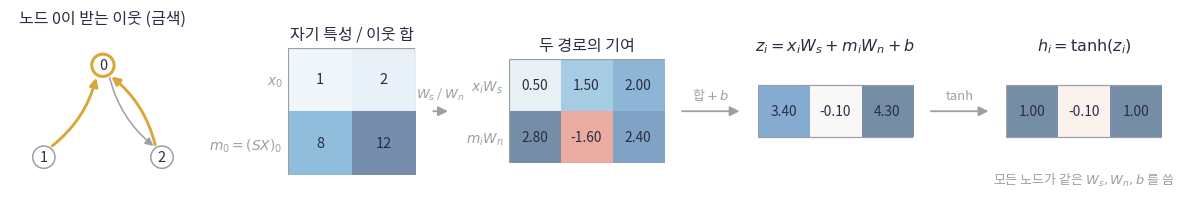

In [8]:
plot_layer_paths(agg_A, tri_positions, 0, agg_X[0], layer_m[0], layer_zs[0], layer_zn[0], layer_Z[0], layer_H[0], [(0, 1), (0, 2)])

🔍 **확인** · 노드 0의 새 표현은 자기 특성 `[1, 2]`를 $W_s$로 옮긴 것과 이웃 합 `[8, 12]`를 $W_n$으로 옮긴 것의 합에 $b$를 더해 tanh를 지난 값입니다. 노드 1은 이웃 합이 0이라 self 경로만 남고, 노드 2도 같은 $W_s, W_n$을 씁니다.
backward에서 노드 0이 받은 기울기는 $W_n^\top$을 거쳐 $S^\top$으로 노드 1·2에게 돌아갑니다. 노드 1이 "받는 이웃이 없다"는 것과 "보내는 곳이 없다"는 것은 다른 일입니다. 아래 검사기의 그래프에는 두 경우가 모두 들어 있습니다.

In [9]:
def gnn_layer_forward(X, A, p, mode="sum"):
    S = aggregation_matrix(A, mode)
    messages = S @ X
    Z = X @ p["Ws"] + messages @ p["Wn"] + p["b"]
    H = np.tanh(Z)
    return H, (X, S, messages, H)


def gnn_layer_backward(dH, cache, p):
    X, S, messages, H = cache
    dZ = dH * (1 - H ** 2)
    D, width = X.shape[-1], H.shape[-1]
    grads = {"Ws": X.reshape(-1, D).T @ dZ.reshape(-1, width),
             "Wn": messages.reshape(-1, D).T @ dZ.reshape(-1, width),
             "b": dZ.sum(axis=(0, 1))}
    dmessages = dZ @ p["Wn"].T
    dX = dZ @ p["Ws"].T + S.swapaxes(-1, -2) @ dmessages
    return dX, grads


def check_gnn_layer(candidate):
    rng = np.random.default_rng(101)
    errors = {}
    A = np.array([[[0., 1., 1., 0.], [0., 0., 0., 0.], [1., 0., 0., 0.], [0., 0., 0., 0.]],
                  [[0., 0., 1., 0.], [1., 0., 0., 0.], [0., 1., 0., 0.], [0., 0., 0., 0.]]])
    for mode in ["sum", "mean"]:
        X = rng.normal(size=(2, 4, 2))
        p = {"Ws": rng.normal(size=(2, 3)) * 0.3, "Wn": rng.normal(size=(2, 3)) * 0.3,
             "b": rng.normal(size=3) * 0.2}
        H, cache = gnn_layer_forward(X, A, p, mode)
        G = rng.normal(size=H.shape)
        dX, grads = candidate(G, cache, p)
        scalar = lambda: float(np.sum(gnn_layer_forward(X, A, p, mode)[0] * G))
        entries = [("X", X, dX)] + [(k, v, grads[k]) for k, v in p.items()]
        for name, value, grad in entries:
            error = rel_error(grad, numerical_gradient(scalar, value))
            assert np.isfinite(error) and error < 2e-6, (mode, name, error)
            errors[f"{mode}/{name}"] = error
    return errors

In [10]:
gnn_layer_errors = check_gnn_layer(gnn_layer_backward)
print("합·평균, 방향·고립 노드의 최대 미분 상대오차:", max(gnn_layer_errors.values()))
layer_H_fn, _ = gnn_layer_forward(agg_X[None], agg_A[None], {"Ws": layer_Ws, "Wn": layer_Wn, "b": layer_b}, "sum")
np.testing.assert_allclose(layer_H_fn[0], layer_H)                                # 위 그림의 손계산과 같음

합·평균, 방향·고립 노드의 최대 미분 상대오차: 1.9854066525716172e-10


🔍 **확인** · 합·평균 집계, 비대칭 $A$, 받는 이웃만 없는 노드, 들어오고 나가는 연결이 모두 없는 고립 노드에서 $X$와 세 파라미터의 미분이 중심차분과 맞습니다. 손계산 노드 0의 $h$도 같습니다.

## 🔑 3. 층을 쌓으면 읽는 범위가 넓어집니다

**이 절에서 가져갈 것:** 한 층은 자기와 1-hop 이웃을, 두 층은 최대 2-hop까지를 읽을 수 있습니다. 그래프 하나의 답을 내려면 노드 표현을 평균낸 readout에 head를 붙이고, backward에서 각 노드는 같은 $dr/M$을 받습니다.

> **용어**
>
> - **hop**: edge를 한 번 건너는 것. $k$층을 쌓으면 최대 $k$-hop 거리의 노드 정보가 닿을 수 있습니다.
> - **readout**: 노드 표현 $M$개를 그래프 하나의 벡터로 줄이는 것. 여기서는 평균 $r=\frac1M\sum_iH_i$.

한 층은 self와 1-hop 이웃을 읽습니다. 두 층은 최대 2-hop까지의 정보를 받을 수 있습니다. 모든 멀리 떨어진 노드의 정보를 즉시 볼 수 있는 것은 아닙니다. `(I+A)^2`의 양수 위치는 두 번의 self/이웃 전달로 도달하는 쌍입니다. 실제 학습된 가중치에 따라 기여가 0이 될 수도 있어, 이는 **가능한 연결 범위**입니다.

노드 분류는 각 $H_i$에 head를 붙입니다. 그래프 분류는 노드 전체를 모은 readout이 필요합니다. 여기서는 평균
$$r=\frac1M\sum_iH_i,\quad logits=rW_o+b_o$$
를 사용합니다. backward에서 각 노드는 같은 $dr/M$을 받습니다. 노드 수가 다른 그래프를 padding해 한 배치로 합치면 유효 노드만 합하고 실제 노드 수로 나눠야 합니다. 이번 구현은 한 배치 안의 M이 같고 padding은 없습니다.

아래는 일렬로 연결한 5노드에서 가운데 노드가 받을 수 있는 범위입니다.

In [11]:
hop_A = np.zeros((5, 5))
for i in range(4):
    hop_A[i, i + 1] = hop_A[i + 1, i] = 1                            # 사슬: 0-1-2-3-4
hop_one = (np.eye(5) + hop_A) > 0                                    # 1층: 자기 + 1-hop
hop_two = ((np.eye(5) + hop_A) @ (np.eye(5) + hop_A)) > 0            # 2층: 최대 2-hop
print("노드 2가 받는 범위 · 1층:", np.flatnonzero(hop_one[2]), "· 2층:", np.flatnonzero(hop_two[2]))

노드 2가 받는 범위 · 1층: [1 2 3] · 2층: [0 1 2 3 4]


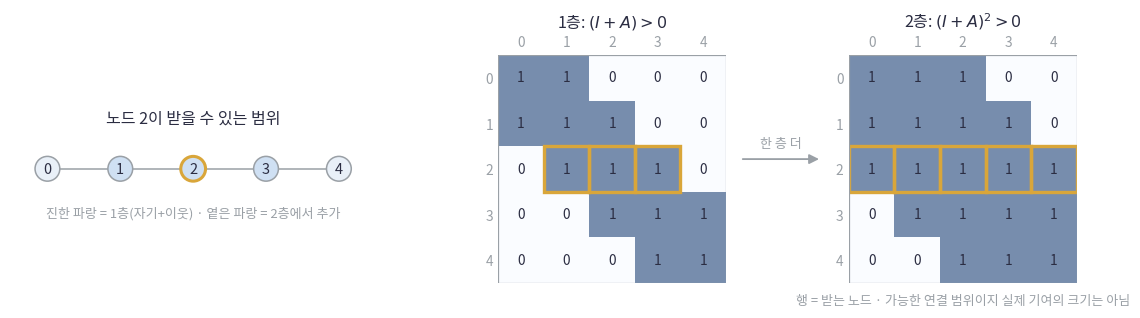

In [12]:
plot_hops(hop_A, line5_positions, 2, hop_one, hop_two)

🔍 **확인** · 한 층 뒤 노드 2는 자기와 1·3만 읽을 수 있고, 두 층 뒤에는 0·4까지 닿습니다. 표의 금색 칸이 그 범위입니다. 끝 노드 0은 두 층 뒤에도 2까지만 닿습니다.
아래 구현은 사슬·별 인접 행렬, 2층 + 평균 readout + head의 forward·backward, 초기화입니다.

In [13]:
def path_adjacency(M):
    A = np.zeros((M, M))
    for i in range(M - 1):
        A[i, i + 1] = A[i + 1, i] = 1
    return A


def star_adjacency(M):
    A = np.zeros((M, M))
    A[0, 1:] = A[1:, 0] = 1
    return A


def graph_forward(X, A, layers, head, mode="sum"):
    H1, cache1 = gnn_layer_forward(X, A, layers[0], mode)
    H2, cache2 = gnn_layer_forward(H1, A, layers[1], mode)
    readout = H2.mean(axis=1)
    return readout @ head["W"] + head["b"], (cache1, cache2, H2.shape, readout)


def graph_backward(dlogits, cache, layers, head, layer_backward_fn=gnn_layer_backward):
    cache1, cache2, shape, readout = cache
    dhead = {"W": readout.T @ dlogits, "b": dlogits.sum(axis=0)}
    dreadout = dlogits @ head["W"].T
    dH2 = np.broadcast_to((dreadout / shape[1])[:, None, :], shape)
    dH1, grad2 = layer_backward_fn(dH2, cache2, layers[1])
    dX, grad1 = layer_backward_fn(dH1, cache1, layers[0])
    return dX, [grad1, grad2], dhead


def init_graph(D=1, H=8, seed=102):
    rng = np.random.default_rng(seed)
    layers = [{"Ws": rng.normal(size=(din, H)) * 0.5 / np.sqrt(din),
               "Wn": rng.normal(size=(din, H)) * 0.2 / np.sqrt(din), "b": np.zeros(H)} for din in [D, H]]
    head = {"W": rng.normal(size=(H, 2)) / np.sqrt(H), "b": np.zeros(2)}
    return layers, head

In [14]:
path5 = path_adjacency(5)
one_hop = (np.eye(5) + path5) > 0
two_hop = ((np.eye(5) + path5) @ (np.eye(5) + path5)) > 0
# 그래프 분류 전체의 입력·모든 파라미터도 독립적인 스칼라와 비교합니다.
probe_X = np.random.default_rng(103).normal(size=(2, 3, 2))
probe_A = np.stack([path_adjacency(3), A_hand[0]])
probe_layers, probe_head = init_graph(2, 3, 104)
probe_logits, probe_cache = graph_forward(probe_X, probe_A, probe_layers, probe_head)
G = np.random.default_rng(105).normal(size=probe_logits.shape)
dX, d_layers, d_head = graph_backward(G, probe_cache, probe_layers, probe_head)
scalar = lambda: float(np.sum(graph_forward(probe_X, probe_A, probe_layers, probe_head)[0] * G))
graph_errors = {"X": rel_error(dX, numerical_gradient(scalar, probe_X))}
for i, (params, grads) in enumerate(zip([*probe_layers, probe_head], [*d_layers, d_head])):
    for k, value in params.items():
        graph_errors[f"{i}/{k}"] = rel_error(grads[k], numerical_gradient(scalar, value))
assert max(graph_errors.values()) < 2e-6
print("2층·readout·head 전체 최대 미분 상대오차:", max(graph_errors.values()))
np.testing.assert_array_equal(path_adjacency(5), hop_A); np.testing.assert_array_equal(two_hop, hop_two)   # 위 그림과 같음

2층·readout·head 전체 최대 미분 상대오차: 5.576446392942628e-10


🔍 **확인** · 2층·readout·head 전체의 입력과 모든 파라미터 미분이 중심차분과 맞습니다. 검사의 배치에는 사슬과 1절의 방향 그래프가 함께 들어 있습니다.

## 🔑 4. 완성 학습: 사슬 모양과 별 모양 그래프 분류

**이 절에서 가져갈 것:** 노드 수·edge 수·평균 degree가 같은 두 그래프도 이웃 구성이 다르면 비선형 층을 거친 노드 표현이 달라지고, 그 평균으로 분류할 수 있습니다. 노드 특성은 거의 상수라 **연결의 형태**만이 정보입니다.

> **용어** · **사슬(path)·별(star) 그래프**: 사슬은 0-1-2-3-4-5로 일렬 연결, 별은 노드 0이 나머지 다섯과 연결. 둘 다 edge 5개이고 평균 degree가 같습니다.

두 그래프는 노드 6개·edge 5개로 같습니다. 초기 특성은 모든 노드에서 1에 작은 잡음을 더한 값입니다. 연결의 형태를 읽어야 합니다. 학습 128개·검증 64개는 두 기본 그래프를 독립적으로 노드 순열·잡음으로 변형합니다. 이는 **두 모양의 새 순열·잡음**에 대한 평가이며, 임의의 새로운 그래프 종류에 대한 성능은 아닙니다.

합 집계→tanh를 두 번 거쳐 평균 readout으로 분류합니다. 잡음을 빼고 초기 특성을 모두 같은 값으로 고정하면, 선형으로 한 번 집계한 뒤 바로 평균낼 때 두 그래프의 평균 degree가 같아 구별하지 못합니다. 잡음 특성에서는 이 등식이 항상 성립하지 않으므로 이 조건을 분리해서 생각합니다. 비선형 노드 표현이 degree의 분포와 이웃 구성을 구별할 기회를 만듭니다.

아래는 두 기본 그래프와 노드별 degree입니다.

In [15]:
path6, star6 = path_adjacency(6), star_adjacency(6)
angles = np.arange(6) * 2 * np.pi / 6
circle = np.stack([np.cos(angles), np.sin(angles)], axis=1)
star_positions = np.vstack([np.zeros(2), np.stack([np.cos(angles[:5] * 6/5), np.sin(angles[:5] * 6/5)], axis=1)])
line_positions = np.stack([np.arange(6), np.zeros(6)], axis=1)
np.testing.assert_allclose(path6.sum(axis=1).mean(), star6.sum(axis=1).mean())
print("path degree:", path6.sum(axis=1), "· star degree:", star6.sum(axis=1))
print("두 그래프 평균 degree:", path6.sum(axis=1).mean())

path degree: [1. 2. 2. 2. 2. 1.] · star degree: [5. 1. 1. 1. 1. 1.]
두 그래프 평균 degree: 1.6666666666666667


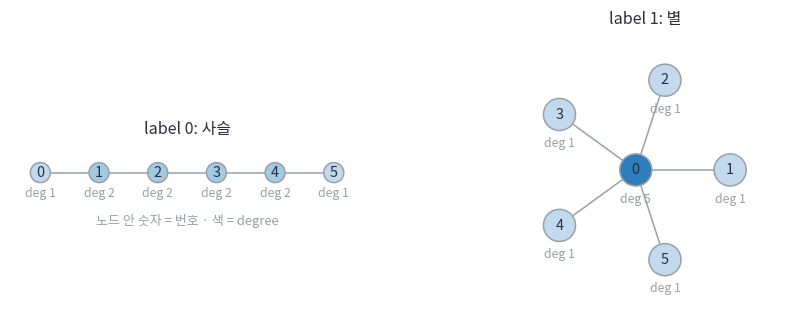

In [16]:
plot_two_graphs([path6, star6], [line_positions, star_positions], [path6.sum(axis=1), star6.sum(axis=1)], ["label 0: 사슬", "label 1: 별"])

🔍 **확인** · 사슬은 degree가 1·2·2·2·2·1, 별은 5·1·1·1·1·1입니다. 합은 둘 다 10이라 평균 degree가 같지만 분포가 다릅니다. 합 집계의 첫 층에서 별의 가운데 노드는 이웃 다섯의 합을, 사슬의 노드는 둘의 합을 받아 표현이 달라집니다.
아래 구현은 데이터 생성(순열·잡음), CE, Adam이고, 이어서 학습합니다.

In [17]:
def graph_data(n, M, seed):
    rng = np.random.default_rng(seed)
    y = np.arange(n) % 2
    rng.shuffle(y)
    matrices = []
    for label in y:
        A = path_adjacency(M) if label == 0 else star_adjacency(M)
        permutation = rng.permutation(M)
        matrices.append(A[permutation][:, permutation])
    X = 1 + rng.normal(0, 0.03, size=(n, M, 1))
    return X, np.stack(matrices), y


def ce_loss(logits, y):
    z = logits - logits.max(axis=-1, keepdims=True)
    logp = z - np.log(np.exp(z).sum(axis=-1, keepdims=True))
    grad = np.exp(logp)
    grad[np.arange(len(y)), y] -= 1
    return -logp[np.arange(len(y)), y].mean(), grad / len(y)


def adam_step(p, grads, state, step, lr=0.02):
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]
        v = 0.999 * v + 0.001 * grads[key] ** 2
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)

In [18]:
X_train, A_train, y_train = graph_data(128, 6, 106)
X_valid, A_valid, y_valid = graph_data(64, 6, 107)
layers, head = init_graph()
params_all = [*layers, head]
states = [{k: (np.zeros_like(v), np.zeros_like(v)) for k, v in params.items()} for params in params_all]
history = {"step": [], "train": [], "valid": []}
for step in range(351):
    logits, cache = graph_forward(X_train, A_train, layers, head)
    loss, dlogits = ce_loss(logits, y_train)
    if step % 35 == 0:
        valid_logits, _ = graph_forward(X_valid, A_valid, layers, head)
        history["step"].append(step)
        history["train"].append(loss)
        history["valid"].append(ce_loss(valid_logits, y_valid)[0])
    if step == 350:
        break
    _, d_layers, d_head = graph_backward(dlogits, cache, layers, head)
    for params, grads, state in zip(params_all, [*d_layers, d_head], states):
        adam_step(params, grads, state, step + 1)
accuracy = np.mean(valid_logits.argmax(axis=-1) == y_valid)
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}")
print(f"검증 CE {history['valid'][-1]:.6f}, 정확도 {accuracy:.1%}, 파라미터 {sum(v.size for p in params_all for v in p.values())}")
assert accuracy > 0.95 and history["train"][-1] < 0.1

학습 CE 0.688424 → 0.000157
검증 CE 0.000155, 정확도 100.0%, 파라미터 178


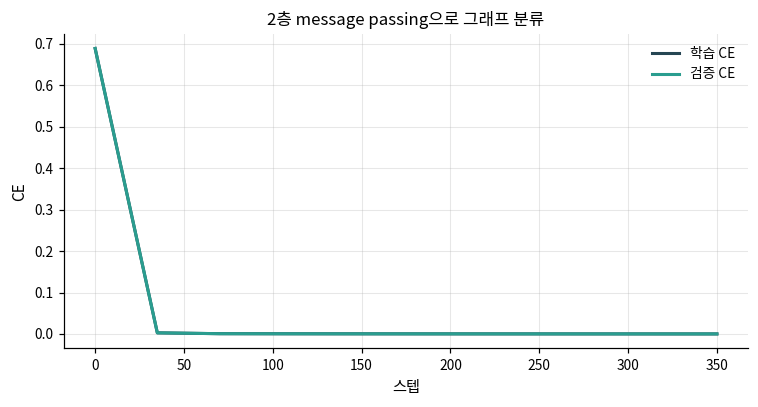

In [19]:
plot_curves(history["step"], {"학습 CE": history["train"], "검증 CE": history["valid"]},
            title="2층 message passing으로 그래프 분류", ylabel="CE")

🔍 **확인** · 검증 정확도가 95%를 넘고 학습 CE가 0.1 아래입니다. 파라미터는 백 몇십 개뿐입니다. 노드 순열이 다른 새 그래프에서도 맞는 이유는 다음 절의 성질 때문입니다.

## 🔑 5. 노드 번호를 바꾸어도 같은 그래프입니다

**이 절에서 가져갈 것:** 순열 $\Pi$로 노드를 재배열하면 $X'=\Pi X$, $A'=\Pi A\Pi^\top$입니다. 행과 열을 **둘 다** 바꿔야 같은 그래프이고, 그러면 노드 출력은 같은 순열로 바뀌고(등변) 그래프 logits는 그대로입니다(불변). backward의 $dX$도 같은 순열로 바뀌며 공유 파라미터의 미분은 같습니다.

> **용어** · **순열 행렬(permutation matrix)** $\Pi$: 행을 재배열하는 0/1 행렬. 코드에서는 `X[perm]`, `A[perm][:, perm]`. 05번의 등변·불변이 여기서는 "노드 번호 바꾸기"에 대한 성질입니다.

순열 행렬 $\Pi$로 노드를 재배열하면 $X'=\Pi X$, $A'=\Pi A\Pi^T$입니다. 받는 행과 보내는 열을 **둘 다** 바꿔야 같은 그래프를 나타냅니다. 그러면 $S'=\Pi S\Pi^T$이므로
$$S'X'=\Pi SX,\qquad H'=\Pi H.$$

재배열한 그래프의 이웃 합은 원래 이웃 합을 같은 순서로 재배열한 것이고, 층 출력도 마찬가지입니다.

노드별 출력은 같은 순서로 바뀌는 **equivariance**, 평균 readout과 그래프 logits는 그대로인 **invariance**를 갖습니다. 이 성질은 파라미터 학습 전후 모두 수식에서 나옵니다.

Backward에서도 상류 노드 기울기를 같은 순열로 바꾸면 dX는 같은 순열로 바뀌고, 공유 파라미터의 미분은 같습니다. 출력만 확인하지 않고 이 연결까지 검사합니다.

아래는 1절 그래프의 번호를 `[2, 0, 1]`로 바꾼 것입니다.

In [20]:
perm_demo = np.array([2, 0, 1])                                    # 새 노드 i = 옛 노드 perm[i]
perm_A = agg_A[perm_demo][:, perm_demo]                            # (3, 3) 행과 열을 함께 재배열
perm_X = agg_X[perm_demo]                                          # (3, 2)
np.testing.assert_allclose(perm_A @ perm_X, (agg_A @ agg_X)[perm_demo])   # 이웃 합도 같은 순열
print("A'\n", perm_A, "\n이웃 합' =", (perm_A @ perm_X).tolist(), "= 원래 이웃 합의 재배열")

A'
 [[0. 1. 0.]
 [1. 0. 1.]
 [0. 0. 0.]] 
이웃 합' = [[1.0, 2.0], [8.0, 12.0], [0.0, 0.0]] = 원래 이웃 합의 재배열


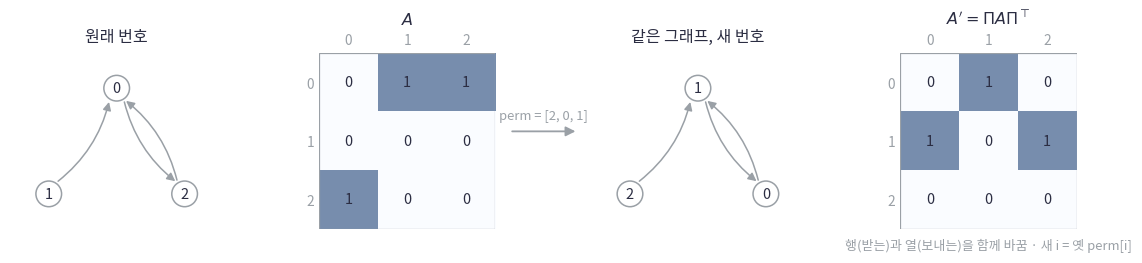

In [21]:
plot_permutation(agg_A, tri_positions, perm_demo, perm_A)

🔍 **확인** · 같은 화살표 그림인데 번호만 바뀌었습니다. 옛 노드 2가 새 0, 옛 0이 새 1, 옛 1이 새 2입니다. $A'$는 $A$의 행과 열을 그 순서로 함께 재배열한 것이고, 이웃 합도 같은 순서로 재배열됩니다.
행만 바꾸고 열을 안 바꾸면 다른 그래프가 됩니다. 아래 검산은 학습한 모델에서 노드 출력·입력 미분의 대응과 그래프 출력·공유 미분의 불변을 확인합니다.

In [22]:
permutation = np.array([4, 1, 5, 0, 3, 2])
Xp = X_valid[:3, permutation]
Ap = A_valid[:3, permutation][:, :, permutation]
for mode in ["sum", "mean"]:
    H, cache = gnn_layer_forward(X_valid[:3], A_valid[:3], layers[0], mode)
    Hp, cachep = gnn_layer_forward(Xp, Ap, layers[0], mode)
    np.testing.assert_allclose(Hp, H[:, permutation], atol=1e-12)
    logits, _ = graph_forward(X_valid[:3], A_valid[:3], layers, head, mode)
    logitsp, _ = graph_forward(Xp, Ap, layers, head, mode)
    np.testing.assert_allclose(logitsp, logits, atol=1e-12)
    G = np.random.default_rng(108).normal(size=H.shape)
    dx, grads = gnn_layer_backward(G, cache, layers[0])
    dxp, gradsp = gnn_layer_backward(G[:, permutation], cachep, layers[0])
    np.testing.assert_allclose(dxp, dx[:, permutation], atol=1e-12)
    for key in grads:
        np.testing.assert_allclose(gradsp[key], grads[key], atol=1e-12)
    print(mode, "노드 출력·입력 미분 대응 / 그래프 출력·공유 미분 불변 통과")

sum 노드 출력·입력 미분 대응 / 그래프 출력·공유 미분 불변 통과
mean 노드 출력·입력 미분 대응 / 그래프 출력·공유 미분 불변 통과


🔍 **확인** · 합·평균 집계 모두에서 노드 출력과 $dX$는 순열대로 바뀌고, 그래프 logits와 $W_s, W_n, b$의 미분은 $10^{-12}$ 안에서 같습니다.

## 🔍 6. 표현력의 한계도 같은 코드로 확인하기

**첫 번째 한계: 평균 집계는 개수를 잃을 수 있습니다.** 모든 초기 노드 특성이 같고 고립 노드가 없다면, path와 star의 이웃 평균은 둘 다 그 같은 특성입니다. 이후 층도 모든 노드에 같은 규칙을 적용하므로 두 그래프의 평균 readout을 구별하지 못합니다. degree를 입력 특성에 넣거나 합 집계를 쓰면 이 특정 정보 손실을 피할 수 있습니다.

**두 번째 한계: 합 집계도 모든 그래프를 구별하지는 못합니다.** 6개 노드의 한 고리와, 각각 3개 노드로 된 분리된 두 고리는 모든 노드의 degree가 2입니다. 초기 특성이 모두 같으면 두 그래프의 각 노드는 매 층 같은 이웃 값 두 개를 받아 같은 표현을 가집니다. 이 message passing과 평균 readout으로는 연결성 차이를 구별할 수 없습니다.

이는 단순히 학습이 덜 된 현상이 아니라, 여기서 정의한 입력과 집계가 구별에 필요한 정보를 전달하지 않는 사례입니다. 모든 GNN 구조에 대한 불가능성 주장으로 넓히지는 않습니다.

In [23]:
constant_X = np.ones((2, 6, 1))
path_star = np.stack([path6, star6])
mean_logits, _ = graph_forward(constant_X, path_star, layers, head, mode="mean")
np.testing.assert_allclose(mean_logits[0], mean_logits[1], atol=1e-12)
cycle6 = path6.copy()
cycle6[0, -1] = cycle6[-1, 0] = 1
triangles = np.zeros((6, 6))
triangles[:3, :3] = np.ones((3, 3)) - np.eye(3)
triangles[3:, 3:] = np.ones((3, 3)) - np.eye(3)
regular_pair = np.stack([cycle6, triangles])
regular_logits, _ = graph_forward(constant_X, regular_pair, layers, head, mode="sum")
np.testing.assert_allclose(regular_logits[0], regular_logits[1], atol=1e-12)
triangle_angles = np.arange(3) * 2 * np.pi / 3
triangle_base = np.stack([np.cos(triangle_angles), np.sin(triangle_angles)], axis=1) * 0.6
triangle_positions = np.vstack([triangle_base + [-1.2, 0], triangle_base + [1.2, 0]])
print("평균 집계의 path/star logits 차이:", np.max(np.abs(mean_logits[0] - mean_logits[1])))
print("합 집계의 한 고리/두 고리 logits 차이:", np.max(np.abs(regular_logits[0] - regular_logits[1])))

평균 집계의 path/star logits 차이: 0.0
합 집계의 한 고리/두 고리 logits 차이: 0.0


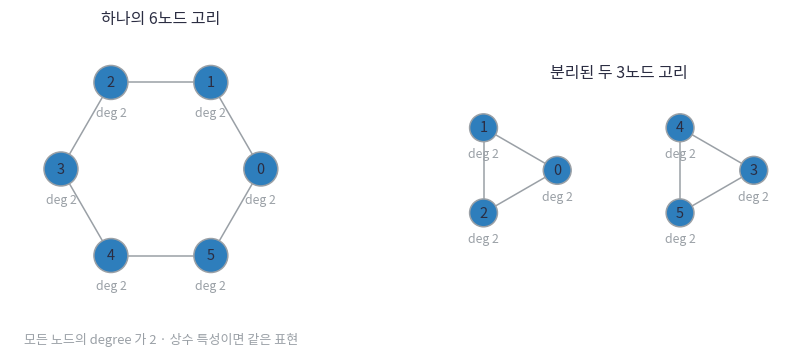

In [24]:
plot_two_graphs([cycle6, triangles], [circle, triangle_positions], [cycle6.sum(axis=1), triangles.sum(axis=1)],
                ["하나의 6노드 고리", "분리된 두 3노드 고리"], note="모든 노드의 degree 가 2 · 상수 특성이면 같은 표현")

🔍 **확인** · 상수 특성에서 평균 집계는 사슬과 별의 logits 차이가 0이고, 합 집계도 한 고리와 두 고리의 차이가 0입니다. 두 그래프의 모든 노드가 매 층 같은 값을 받기 때문입니다. 학습된 모델도 이 두 입력은 구별하지 못합니다.

## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 평균 집계 행렬 (1절)

0/1 인접 행렬 `A` $(B,M,M)$에서 각 행을 degree로 나눈 `S`를 만드는 두 줄을 채우세요. degree가 0인 행은 0으로 남깁니다.

In [25]:
def exercise_mean_aggregation(A):
    assert A.ndim == 3 and np.all((A == 0) | (A == 1))
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: degree = 행마다 받는 이웃 수 (B, M, 1), S = A 를 max(degree, 1) 로 나눈 값
    ### 힌트: A.sum(axis=-1, keepdims=True), np.maximum(degree, 1)
    raise NotImplementedError
    return S

In [26]:
def check_mean_aggregation(candidate):
    np.testing.assert_allclose(candidate(agg_A[None])[0], agg_S)                                     # 1절 손계산
    np.testing.assert_allclose(candidate(agg_A[None])[0] @ agg_X, agg_mean)
    A_c = np.stack([path_adjacency(6), star_adjacency(6)])
    np.testing.assert_allclose(candidate(A_c), aggregation_matrix(A_c, "mean"))
    np.testing.assert_allclose(candidate(A_c).sum(axis=-1), 1.)                                       # 이웃이 있으면 행 합 1
    print("평균 집계 행렬: 손계산·aggregation_matrix 와 일치합니다.")

run_check(check_mean_aggregation, exercise_mean_aggregation, hint="degree = A.sum(axis=-1, keepdims=True); S = A / np.maximum(degree, 1)")

☐ exercise_mean_aggregation: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: degree = A.sum(axis=-1, keepdims=True); S = A / np.maximum(degree, 1)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
degree = A.sum(axis=-1, keepdims=True)
S = A / np.maximum(degree, 1)
```

</details>

### ✏️ 연습 B · 한 층의 forward (2절)

노드 특성 `X` $(B,M,D)$, 집계 행렬 `S`, 파라미터 `p`에서 `Z`와 `H`를 만드는 두 줄을 채우세요.

In [27]:
def exercise_gnn_layer(X, S, p):
    assert X.shape[-1] == p["Ws"].shape[0] == p["Wn"].shape[0]
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: Z = 자기 특성 @ Ws + (이웃 집계 S @ X) @ Wn + b, H = tanh(Z)
    ### 힌트: 2절 gnn_layer_forward 의 두 줄입니다.
    raise NotImplementedError
    return H, Z

In [28]:
def check_gnn_layer_forward(candidate):
    H_a, Z_a = candidate(agg_X[None], agg_A[None], {"Ws": layer_Ws, "Wn": layer_Wn, "b": layer_b})
    np.testing.assert_allclose(Z_a[0], layer_Z); np.testing.assert_allclose(H_a[0], layer_H)          # 2절 손계산
    rng_c = np.random.default_rng(101)
    A_c = np.stack([path_adjacency(4), star_adjacency(4)])
    X_c = rng_c.normal(size=(2, 4, 2)); p_c = {"Ws": rng_c.normal(size=(2, 3)), "Wn": rng_c.normal(size=(2, 3)), "b": rng_c.normal(size=3)}
    S_c = aggregation_matrix(A_c, "mean")
    np.testing.assert_allclose(candidate(X_c, S_c, p_c)[0], gnn_layer_forward(X_c, A_c, p_c, "mean")[0])
    print("한 층의 forward: 손계산·gnn_layer_forward 와 일치합니다.")

run_check(check_gnn_layer_forward, exercise_gnn_layer, hint="Z = X @ p['Ws'] + (S @ X) @ p['Wn'] + p['b']; H = np.tanh(Z)")

☐ exercise_gnn_layer: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Z = X @ p['Ws'] + (S @ X) @ p['Wn'] + p['b']; H = np.tanh(Z)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Z = X @ p["Ws"] + (S @ X) @ p["Wn"] + p["b"]
H = np.tanh(Z)
```

</details>

### ✏️ 연습 C · 이웃 경로의 backward (2절)

활성 전 값의 기울기 `dZ` $(B,M,H)$, 집계 행렬 `S`, `Wn`에서 이웃 경로로 돌아오는 입력 기울기를 만드는 한 줄을 채우세요. 받는 노드에서 보내는 노드로 가므로 전치가 필요합니다.

In [29]:
def exercise_neighbor_backward(dZ, S, Wn):
    assert dZ.shape[-1] == Wn.shape[1]
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dX_neighbor = S 의 전치(마지막 두 축) @ (dZ 를 Wn 의 전치로 되돌린 값)
    ### 힌트: S.swapaxes(-1, -2), 2절의 dX 둘째 항입니다.
    raise NotImplementedError
    return dX_neighbor

In [30]:
def check_neighbor_backward(candidate):
    rng_c = np.random.default_rng(102)
    A_c = np.stack([agg_A, path_adjacency(3)])
    X_c = rng_c.normal(size=(2, 3, 2)); p_c = {"Ws": rng_c.normal(size=(2, 3)), "Wn": rng_c.normal(size=(2, 3)), "b": np.zeros(3)}
    for mode in ("sum", "mean"):
        H_c, cache_c = gnn_layer_forward(X_c, A_c, p_c, mode)
        dH_c = rng_c.normal(size=H_c.shape)
        dZ_c = dH_c * (1 - H_c ** 2)
        dX_ref, _ = gnn_layer_backward(dH_c, cache_c, p_c)
        np.testing.assert_allclose(dZ_c @ p_c["Ws"].T + candidate(dZ_c, cache_c[1], p_c["Wn"]), dX_ref)   # self + neighbor = dX
    print("이웃 경로의 backward: gnn_layer_backward 와 일치합니다 (전치 방향이 맞습니다).")

run_check(check_neighbor_backward, exercise_neighbor_backward, hint="dX_neighbor = S.swapaxes(-1, -2) @ (dZ @ Wn.T)")

☐ exercise_neighbor_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dX_neighbor = S.swapaxes(-1, -2) @ (dZ @ Wn.T)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dX_neighbor = S.swapaxes(-1, -2) @ (dZ @ Wn.T)
```

</details>

### ✏️ 연습 D · 평균 readout의 backward (3절)

readout의 기울기 `dreadout` $(B,H)$와 노드 수 `M`에서 각 노드에 나눠 줄 `dH` $(B,M,H)$를 만드는 한 줄을 채우세요.

In [31]:
def exercise_readout_backward(dreadout, M):
    B, H = dreadout.shape
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dH = dreadout / M 을 노드 축에 M 번 복제한 (B, M, H) 배열
    ### 힌트: np.broadcast_to((dreadout / M)[:, None, :], (B, M, H)) 또는 np.repeat
    raise NotImplementedError
    return dH

In [32]:
def check_readout_backward(candidate):
    rng_c = np.random.default_rng(103)
    H_c = rng_c.normal(size=(2, 5, 3)); G_c = rng_c.normal(size=(2, 3))
    dH_c = candidate(G_c, 5)
    assert dH_c.shape == (2, 5, 3)
    numeric_c = numerical_gradient(lambda: float(np.sum(H_c.mean(axis=1) * G_c)), H_c)              # readout = 노드 평균
    np.testing.assert_allclose(dH_c, numeric_c, atol=1e-8)
    print("평균 readout backward: 모든 노드가 같은 dr/M 을 받습니다.")

run_check(check_readout_backward, exercise_readout_backward, hint="dH = np.broadcast_to((dreadout / M)[:, None, :], (B, M, H))")

☐ exercise_readout_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dH = np.broadcast_to((dreadout / M)[:, None, :], (B, M, H))


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dH = np.broadcast_to((dreadout / M)[:, None, :], (B, M, H))
```

</details>

### 🔍 완성 예제 · 검사기가 잡는 오답과 노드 수 변경

아래는 이웃 기울기를 forward와 같은 방향($S$ 그대로)으로 보낸 오답입니다. 2절의 검사기가 거부하는지 실행합니다. 이어서 노드 6개로 학습한 모델을 추가 갱신 없이 8노드 그래프에 적용합니다. 가중치 shape는 그대로지만 데이터의 degree 분포가 달라집니다.

In [33]:
def wrong_neighbor_direction(dH, cache, p):
    X, S, messages, H = cache
    _, grads = gnn_layer_backward(dH, cache, p)
    dZ = dH * (1 - H ** 2)
    dX = dZ @ p["Ws"].T + S @ (dZ @ p["Wn"].T)
    return dX, grads

In [34]:
try:
    check_gnn_layer(wrong_neighbor_direction)
except AssertionError as error:
    print("의도적 오답 검출: 이웃 미분의 전치 누락", error)
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")
X8, A8, y8 = graph_data(64, 8, 109)
logits8, _ = graph_forward(X8, A8, layers, head)
print(f"추가 갱신 없는 8노드: CE {ce_loss(logits8, y8)[0]:.6f}, 정확도 {np.mean(logits8.argmax(axis=-1) == y8):.1%}")

의도적 오답 검출: 이웃 미분의 전치 누락 ('sum', 'X', 0.848897776249473)
추가 갱신 없는 8노드: CE 0.000045, 정확도 100.0%


### 📎 공유 방식을 연결하기

| 구조 | 이웃을 정하는 방법 | 파라미터가 공유되는 축 | 입력 기울기가 모이는 이유 |
|---|---|---|---|
| CNN | 공간의 고정된 패치 | 이미지의 위치 | 한 픽셀이 여러 패치에 등장 |
| RNN·LSTM·GRU | 이전 시각의 상태 | 시간 | 같은 상태가 미래 경로와 손실에 사용 |
| GNN | 주어진 edge | 노드·edge의 반복 규칙 | 한 노드가 여러 이웃에게 정보를 전달 |
| Attention·Transformer | Q·K로 계산한 가중치와 mask | 위치의 투영·FFN | 각 값이 여러 query에 읽힘 |

공유는 같은 변수를 여러 계산에 다시 사용한다는 뜻이고, 미분은 그 사용 경로들의 **합**입니다. 이제 구조를 바꿀 때 무엇이 바뀌고 CE·MSE·optimizer 중 무엇을 유지할 수 있는지 구분할 수 있어야 합니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 인접 행렬 방향, 자기 경로, 이웃 집계, readout의 역할을 구분할 수 있나요? → 1–3절
- **수식:** $S$의 정규화와 전치가 나타나는 위치, 노드 평균의 미분을 쓸 수 있나요? → 1–3절
- **구현:** 방향·고립 노드·노드 수 변화를 처리하며 공유 미분을 누적할 수 있나요? → 2·4절
- **변형:** 노드 출력의 등변성과 그래프 출력의 불변성을 검산하고, 노드 분류로 바꾸면 readout 대신 각 $H_i$에 head를 붙일 때 logits의 shape와 평균낼 유효 노드 수를 말할 수 있나요? → 3·5절

기본 아키텍처 05–10을 마쳤습니다. 다음은 [11 · 투영·공분산·SVD·PCA](../02_연결/11_linear_algebra.ipynb)입니다. 구조가 아니라 학습 목적과 표현을 다루는 연결 기초로 넘어갑니다.

📎 [Gilmer 등의 Message Passing Neural Networks](https://arxiv.org/abs/1704.01212)는 메시지 전달과 readout으로 그래프 모델을 설명하는 틀을 제공합니다. 여기서는 edge 특성 없이 self와 합/평균 이웃을 결합한 교육용 인스턴스를 구현했으며, 특정 GCN·GraphSAGE 라이브러리의 동일 재현은 아닙니다.